In [23]:
#import block
import pandas as pd
from keybert import KeyBERT
from collections import Counter
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
import spacy
from nltk.tokenize import sent_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util



#check for progress becausse plot pattern takes ages
from tqdm import tqdm
tqdm.pandas()




In [24]:
#load model
model=KeyBERT()
sim_model = SentenceTransformer('all-MiniLM-L6-v2')
nlp = spacy.load("en_core_web_sm")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1192.35it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1121.57it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:


def contains_name_or_place(text):
    """Helper function checking if its name or place"""
    doc = nlp(str(text))
    for ent in doc.ents:
        if ent.label_ in ['PERSON', 'GPE', 'LOC']:
            return True
    return False

In [ ]:


def plot_pattern(dataframe, column, ngram_range=(2,3), top_phrase_per_plot=20, top_plots=5, threshold=0.75,clear_0_movies= False):
    """
    Detects plot patterns in genres and returns top_n phrases of length ngram range
    returns dataframe with id,plotpoint and Count of frequency
    """
    # clear 0 box office movies out to be faster
    if clear_0_movies:
        dataframe = dataframe[dataframe['box_office_worldwide'] > 0].copy()

    # extract keywords 
    dataframe['extracted_plotpoints'] = dataframe[column].progress_apply( 
        lambda x: [keyword[0] for keyword in model.extract_keywords(str(x), use_mmr=True, diversity=threshold, keyphrase_ngram_range=ngram_range, stop_words='english', top_n=top_phrase_per_plot)]
    )
    
    # blacklist for all unwated keyphrases
    blacklist = [
        "year old", "years later", "years ago", "days later", "real life",
        "don know", "new york", "los angeles", "high school", "tells",
        "takes place", "tells story", "soon discover", "soon realizes",
        "things happen", "begin happen", "makes way", "long ago"
        "face face", "looks like", "long time", "outside world", "young son",
        "middle night", "true story", "strange things", "years old", "loved ones","kong save luigi",
        "sauron evil army", "gandalf rescued necromancer", "quest destroy ring", "infinity castle tanjiro",
        "demon slayer corps", "corps drawn infinity", "awaken legendary pokémon", "straw hat",                
        "catastrophe souls nezha", "spirit bead reincarnated", "oceania dangerous long", "wicked witch west",         
        "school witchcraft","soon finds", "mysterious reason", "brand new", "change way", "20 years", "13 year",
        "year old self","cameron diaz", "grint hermione", "donkey eddie murphy", "ella cinderella", "begins bella vampire","plot unknown",
        "sequel avatar 2022", "animated adventure", "story set", "taking place", "500 years","boy named","girl named","soon discovers"
        "face face","tries make","place years","quickly turns","things worse","things begin","took place","long ago","present day","film based",
        "try way","people lives","12 year","movie plot omdb","finds way"
        ]
    
    all_plotpoints = []
    # 
    for plotlist in dataframe['extracted_plotpoints']:
        for plotpoint in plotlist:
            if plotpoint not in blacklist:
                all_plotpoints.append(plotpoint)
                
    
    plot_points_count = Counter(all_plotpoints)
    
    
    unique_phrases = []
    
    
    for phrase, count in plot_points_count.most_common(2000): 
        
        if not contains_name_or_place(phrase):
            unique_phrases.append(phrase)
            
        
        if len(unique_phrases) == 1000:
            break
    
    
    embeddings = sim_model.encode(unique_phrases, show_progress_bar=True)
    
    merged_counts = {}
    done_word = set()
    
    cosine_scores_matrix = util.cos_sim(embeddings, embeddings)
    
    for i in tqdm(range(len(unique_phrases))):
        if i in done_word:
            continue
            
        main_word = unique_phrases[i]
        main_count = plot_points_count[main_word]
        
        for j in range(i + 1, len(unique_phrases)):
            if j in done_word:
                continue
                
            similarity = cosine_scores_matrix[i][j].item()
            
            
            if similarity >= threshold:
                main_count += plot_points_count[unique_phrases[j]]
                done_word.add(j)
                
        merged_counts[main_word] = main_count
        done_word.add(i)

    sorted_result = sorted(merged_counts.items(), key=lambda x: x[1], reverse=True)
    

    
    plot_point_list = []
    # Create dictionary with most common plot phrases and their count
    for phrase, count in sorted_result[:top_plots]:
        plot_point_list.append({'Plotphrase': phrase, 'Count': count})
        
    plot_point_dataframe = pd.DataFrame(plot_point_list)
    
    return plot_point_dataframe

In [27]:

def compare_movies_with_plotphrases(dataframe_untouched, dataframe_plotphrases, column_box_office, column_plotphrase, sim_model, threshold):
    
    
    dataframe_untouched = dataframe_untouched[dataframe_untouched[column_box_office] > 0]

    # convert
    list_plotphrase = list(dataframe_plotphrases['Plotphrase'])

    # transform plotphrases into embeddings
    top_embeddings = sim_model.encode(list_plotphrase)

    # Create lists for debugging and one complete dataframe
    phrase_used_list = []
    best_phrase_list = []
    best_score_list = []
    
    for movie_plot in dataframe_untouched[column_plotphrase]:
        
        # Common values if not existing
        movie_uses_plotphrase = False
        best_phrase = "None"
        best_score = 0.0
        
        check_text = str(movie_plot)

        if len(check_text.strip()) > 0:
            sentences = sent_tokenize(check_text)
            
            if len(sentences) > 0:
                
                sentence_embeddings = sim_model.encode(sentences)
                hits = util.cos_sim(sentence_embeddings, top_embeddings)

                best_score = hits.max().item()
                
                
                max_idx = hits.argmax().item()
                phrase_idx = max_idx % hits.shape[1]
                best_phrase = list_plotphrase[phrase_idx]

                # 3. Threshold check
                if best_score >= threshold:
                    movie_uses_plotphrase = True

        # This movie values
        phrase_used_list.append(movie_uses_plotphrase)
        best_phrase_list.append(best_phrase)
        best_score_list.append(best_score)

    
    dataframe_untouched['Used_Plotphrases'] = phrase_used_list
    dataframe_untouched['Best_Match_Phrase'] = best_phrase_list
    dataframe_untouched['Similarity_Score'] = best_score_list

    #debugging
    #csv_filename = 'movies_debug.csv'
    #dataframe_untouched.to_csv(csv_filename, index=False, sep=';', encoding='utf-8')
    #print(f"Create debug file: {csv_filename}")

    # Print result 
    count_movie = dataframe_untouched['Used_Plotphrases'].value_counts()
    print("Movies used Plot")
    print(count_movie)
    succes = dataframe_untouched.groupby('Used_Plotphrases')[column_box_office].mean()
    succes_readable = succes.apply(lambda x: f"{x:,.0f} $")
    print("")
    print("Average Sucess:")
    print(succes_readable)
    
    return dataframe_untouched

In [28]:
def wordmap(dataframe):
    frequency= dataframe.set_index('Plotphrase')['Count'].to_dict()

    wordmap = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(frequency)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordmap, interpolation='bilinear')
    plt.axis('off')  
    plt.title("Wordmap for Genre Tropes")
    
    plt.show()
    

In [29]:
def plot_box_office_boxplot(dataframe, column_box_office,genre):
    plt.figure(figsize=(10, 6))
    
   
    sns.boxplot(
        data=dataframe, 
        x='Used_Plotphrases', 
        y=column_box_office, 
        palette=['#ff9999', '#66b3ff'] #False und True
    )
    
    plt.title(f'Distribution of Box offfice for {genre} movies ', fontsize=14)
    plt.xlabel('Using common plotphrases?', fontsize=12)
    plt.ylabel('Box office revenue in $', fontsize=12)
    
    # for readability
    plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
    
    
    plt.show()

100%|██████████| 2000/2000 [02:24<00:00, 13.88it/s]


Starte Embedding für 1000 saubere Phrasen...


100%|██████████| 1000/1000 [00:00<00:00, 2158.58it/s]


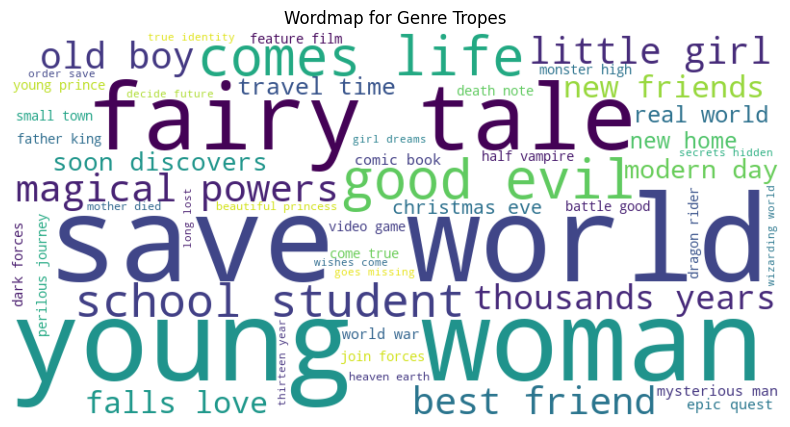

In [30]:
#testblock
data_test= pd.read_csv('movies_plot_fantasy.csv')
save_frame_fantasy=(plot_pattern(data_test,'plot',top_plots=50,threshold=0.5,top_phrase_per_plot=75))
save_frame_fantasy.to_csv('fantasy_plotframe.csv')
wordmap(save_frame_fantasy)





100%|██████████| 2000/2000 [02:00<00:00, 16.60it/s]


Starte Embedding für 1000 saubere Phrasen...


100%|██████████| 1000/1000 [00:00<00:00, 2484.66it/s]


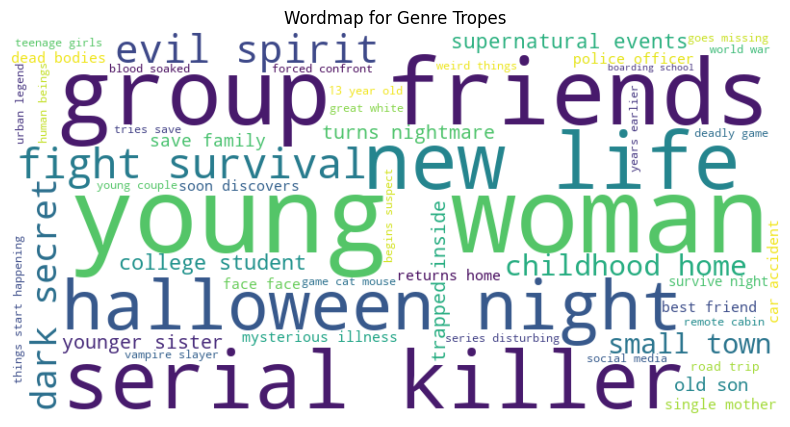

In [31]:
data_test_horror= pd.read_csv('movies_plot_horror.csv')
save_frame_horror=save_frame=(plot_pattern(data_test_horror,'plot',top_plots=50,threshold=0.5,top_phrase_per_plot=75))
save_frame_horror.to_csv('horror_plotframe.csv')
wordmap(save_frame_horror)


Movies used Plot
Used_Plotphrases
False    955
True      62
Name: count, dtype: int64

Average Sucess:
Used_Plotphrases
False    128,490,407 $
True     104,515,259 $
Name: box_office_worldwide, dtype: str


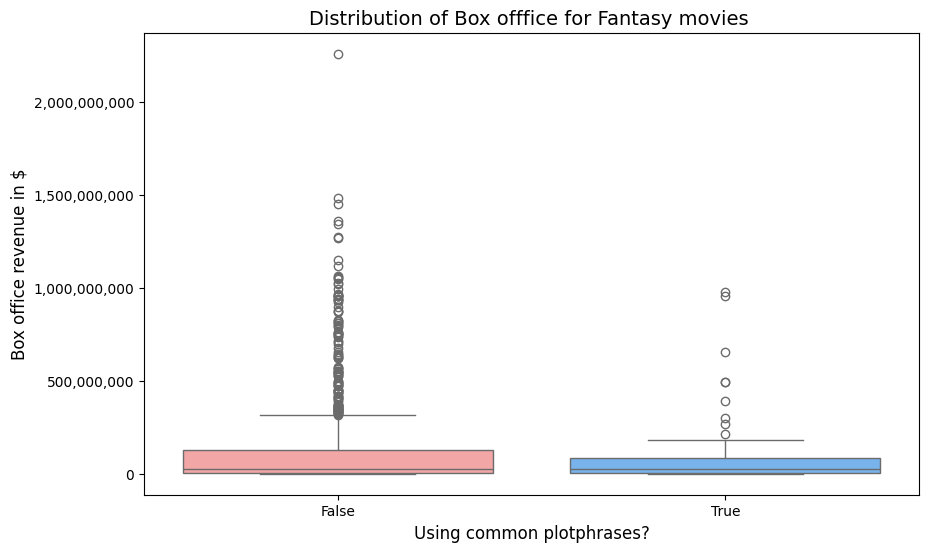

In [32]:

result_fantasy = compare_movies_with_plotphrases(data_test,save_frame_fantasy,'box_office_worldwide','plot',sim_model=sim_model,threshold=0.5)
plot_box_office_boxplot(result_fantasy,'box_office_worldwide',genre="Fantasy")

Movies used Plot
Used_Plotphrases
False    1119
True      124
Name: count, dtype: int64

Average Sucess:
Used_Plotphrases
False    33,285,774 $
True     42,630,021 $
Name: box_office_worldwide, dtype: str


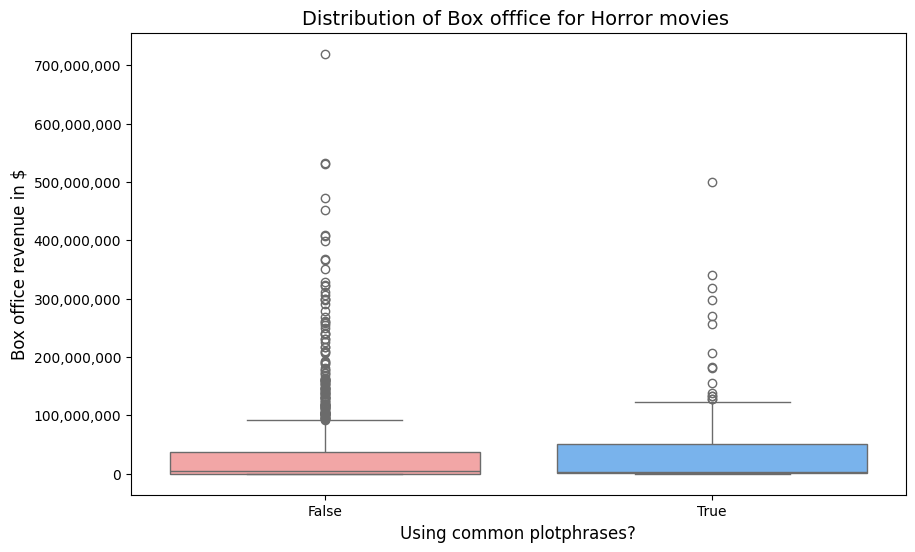

In [33]:
result_horror = compare_movies_with_plotphrases(data_test_horror,save_frame_horror,'box_office_worldwide','plot',sim_model=sim_model,threshold=0.5)
plot_box_office_boxplot(result_horror,'box_office_worldwide',genre="Horror")


-Test